# 🧠 Stroke Risk Dataset — EDA & Predictive Modelling

**Goal**: Explore the stroke risk data through Exploratory Data Analysis (EDA), and build the **best predictive model** for `At Risk (Binary)` using cross-validation and hyperparameter tuning, wrapped in a clean scikit-learn `Pipeline`.

> ℹ️ **Note on data cleaning**: The original dataset contained a continuous `Stroke Risk (%)` column that was used to *generate* the target (`At Risk = 1` exactly when `Stroke Risk (%) >= 50`). That made it **leaked**/redundant, so the column was **removed from the dataset file** before this analysis (raw backup kept as `stroke_risk_dataset_raw.csv`). Only the 15 clinical symptom indicators and `Age` are used as features.

---

## 1. Setup & Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_val_score,
    GridSearchCV, cross_validate
)
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, auc, confusion_matrix,
    ConfusionMatrixDisplay, classification_report
)

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
pd.set_option('display.max_columns', None)

print('Setup complete.')

Setup complete.


## 2. Load the Data (cleaned — leaked column already removed)

In [2]:
# Load the cleaned dataset
data_path = 'stroke_risk_dataset.csv'
df = pd.read_csv(data_path)

print('Shape:', df.shape)
print('Columns:', df.columns.tolist())
df.head()

Shape: (70000, 17)
Columns: ['Chest Pain', 'Shortness of Breath', 'Irregular Heartbeat', 'Fatigue & Weakness', 'Dizziness', 'Swelling (Edema)', 'Pain in Neck/Jaw/Shoulder/Back', 'Excessive Sweating', 'Persistent Cough', 'Nausea/Vomiting', 'High Blood Pressure', 'Chest Discomfort (Activity)', 'Cold Hands/Feet', 'Snoring/Sleep Apnea', 'Anxiety/Feeling of Doom', 'Age', 'At Risk (Binary)']


,Chest Pain,Shortness of Breath,Irregular Heartbeat,Fatigue & Weakness,Dizziness,Swelling (Edema),Pain in Neck/Jaw/Shoulder/Back,Excessive Sweating,Persistent Cough,Nausea/Vomiting,High Blood Pressure,Chest Discomfort (Activity),Cold Hands/Feet,Snoring/Sleep Apnea,Anxiety/Feeling of Doom,Age,At Risk (Binary)
0,0,1,1,1,0,0,0,1,1,1,0,1,1,0,0,54,1
1,0,0,1,0,0,1,0,0,0,0,1,0,1,1,0,49,0
2,1,0,0,1,1,1,0,0,1,0,0,0,0,1,0,62,1
3,1,0,1,1,0,1,1,1,1,1,1,0,0,0,0,48,1
4,0,0,1,0,0,1,0,1,0,1,1,0,0,1,1,61,1


In [3]:
# Basic info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype
---  ------                          --------------  -----
 0   Chest Pain                      70000 non-null  int64
 1   Shortness of Breath             70000 non-null  int64
 2   Irregular Heartbeat             70000 non-null  int64
 3   Fatigue & Weakness              70000 non-null  int64
 4   Dizziness                       70000 non-null  int64
 5   Swelling (Edema)                70000 non-null  int64
 6   Pain in Neck/Jaw/Shoulder/Back  70000 non-null  int64
 7   Excessive Sweating              70000 non-null  int64
 8   Persistent Cough                70000 non-null  int64
 9   Nausea/Vomiting                 70000 non-null  int64
 10  High Blood Pressure             70000 non-null  int64
 11  Chest Discomfort (Activity)     70000 non-null  int64
 12  Cold Hands/Feet                 70000 non-null  int64
 13  S

In [4]:
# Statistical summary
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Chest Pain,70000.0,0.501871,0.500000,0.0,0.0,1.0,1.0,1.0
Shortness of Breath,70000.0,0.496471,0.499991,0.0,0.0,0.0,1.0,1.0
Irregular Heartbeat,70000.0,0.498886,0.500002,0.0,0.0,0.0,1.0,1.0
Fatigue & Weakness,70000.0,0.500100,0.500004,0.0,0.0,1.0,1.0,1.0
Dizziness,70000.0,0.503043,0.499994,0.0,0.0,1.0,1.0,1.0
Swelling (Edema),70000.0,0.500557,0.500003,0.0,0.0,1.0,1.0,1.0
Pain in Neck/Jaw/Shoulder/Back,70000.0,0.499186,0.500003,0.0,0.0,0.0,1.0,1.0
Excessive Sweating,70000.0,0.503671,0.499990,0.0,0.0,1.0,1.0,1.0
Persistent Cough,70000.0,0.500800,0.500003,0.0,0.0,1.0,1.0,1.0
Nausea/Vomiting,70000.0,0.501943,0.500000,0.0,0.0,1.0,1.0,1.0


## 3. Exploratory Data Analysis (EDA)

### 3.1 Target Variable Distribution

At Risk (Binary)
1    45444
0    24556
Name: count, dtype: int64

Percentage:
At Risk (Binary)
1    64.92
0    35.08
Name: proportion, dtype: float64


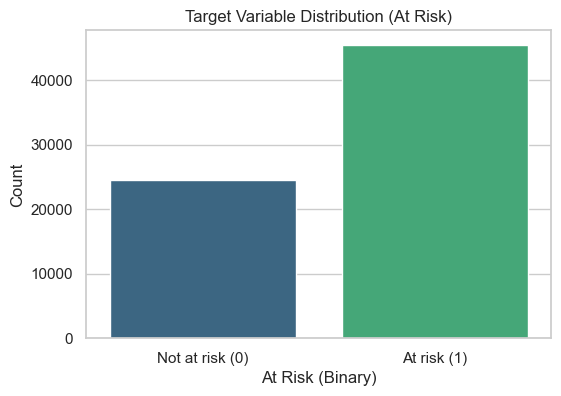

In [5]:
# Target distribution
print(df['At Risk (Binary)'].value_counts())
print('\nPercentage:')
print((df['At Risk (Binary)'].value_counts(normalize=True) * 100).round(2))

plt.figure(figsize=(6, 4))
sns.countplot(x='At Risk (Binary)', data=df, palette='viridis')
plt.xticks([0, 1], ['Not at risk (0)', 'At risk (1)'])
plt.title('Target Variable Distribution (At Risk)')
plt.ylabel('Count')
plt.show()

### 3.2 Symptom Frequency (the 15 binary clinical features)

Symptom prevalence (%):
Excessive Sweating                50.37
Dizziness                         50.30
Nausea/Vomiting                   50.19
Chest Pain                        50.19
Persistent Cough                  50.08
Snoring/Sleep Apnea               50.07
High Blood Pressure               50.06
Swelling (Edema)                  50.06
Fatigue & Weakness                50.01
Anxiety/Feeling of Doom           49.99
Chest Discomfort (Activity)       49.96
Pain in Neck/Jaw/Shoulder/Back    49.92
Irregular Heartbeat               49.89
Cold Hands/Feet                   49.89
Shortness of Breath               49.65
dtype: float64


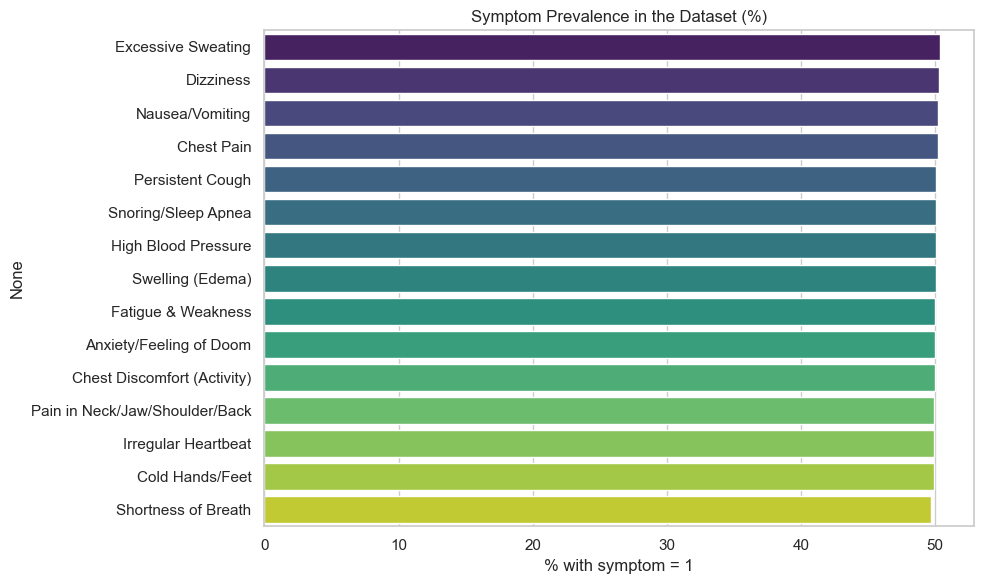

In [6]:
# Prevalence of each symptom
symptom_cols = [c for c in df.columns if c not in ['Age', 'At Risk (Binary)']]

prevalence = df[symptom_cols].mean().sort_values(ascending=False) * 100
print('Symptom prevalence (%):')
print(prevalence.round(2))

plt.figure(figsize=(10, 6))
sns.barplot(x=prevalence.values, y=prevalence.index, palette='viridis')
plt.title('Symptom Prevalence in the Dataset (%)')
plt.xlabel('% with symptom = 1')
plt.tight_layout()
plt.show()

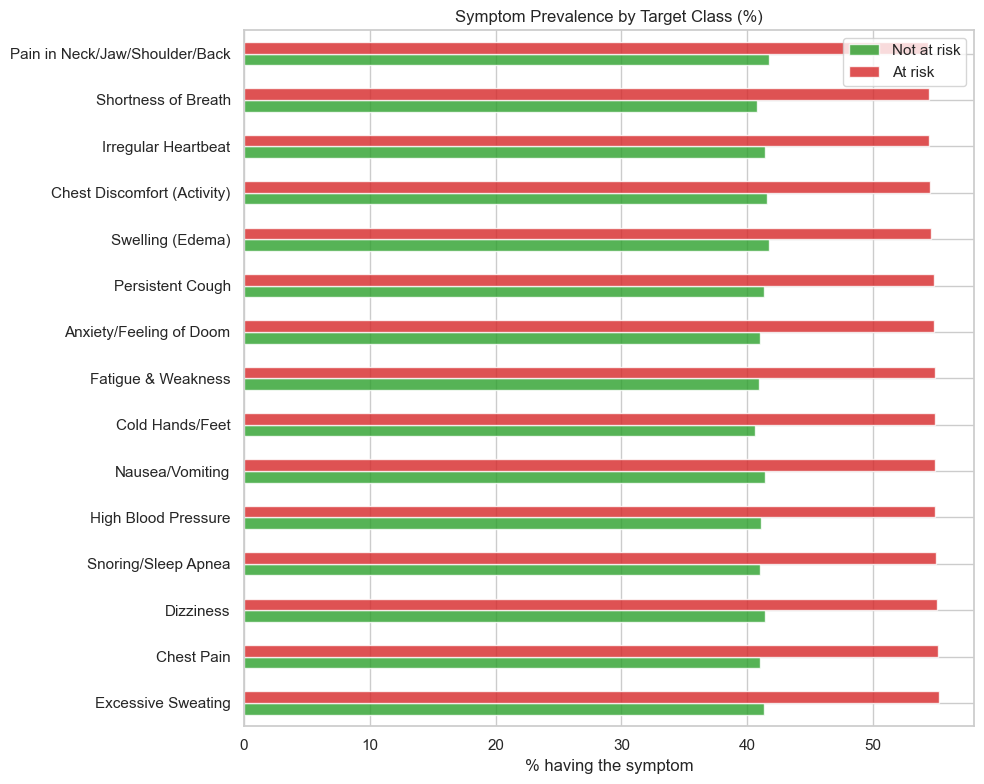

In [7]:
# Symptom prevalence split by target
prev_by_target = df.groupby('At Risk (Binary)')[symptom_cols].mean().T * 100
prev_by_target.columns = ['Not at risk', 'At risk']
prev_by_target = prev_by_target.sort_values('At risk', ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
prev_by_target.plot(kind='barh', ax=ax, color=['#2ca02c', '#d62728'], alpha=0.8)
plt.title('Symptom Prevalence by Target Class (%)')
plt.xlabel('% having the symptom')
plt.tight_layout()
plt.show()

### 3.3 Age Distribution

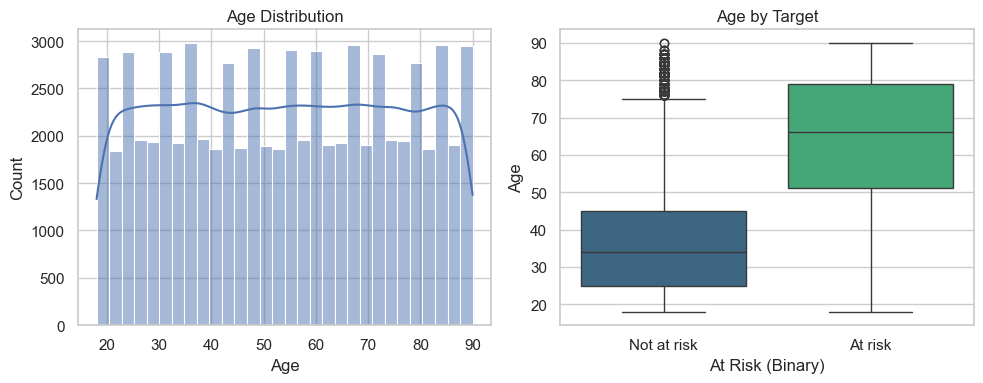

In [8]:
# Age distribution
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.histplot(df['Age'], bins=30, kde=True)
plt.title('Age Distribution')

plt.subplot(1, 2, 2)
sns.boxplot(x='At Risk (Binary)', y='Age', data=df, palette='viridis')
plt.xticks([0, 1], ['Not at risk', 'At risk'])
plt.title('Age by Target')
plt.tight_layout()
plt.show()

In [9]:
print(df.groupby('At Risk (Binary)')['Age'].describe().round(2))

                    count   mean    std   min   25%   50%   75%   max
At Risk (Binary)                                                     
0                 24556.0  36.51  14.03  18.0  25.0  34.0  45.0  90.0
1                 45444.0  63.54  17.93  18.0  51.0  66.0  79.0  90.0


### 3.4 Correlation Analysis

Correlation with target (At Risk):
Age                               0.612
Cold Hands/Feet                   0.137
Chest Pain                        0.135
Snoring/Sleep Apnea               0.134
Fatigue & Weakness                0.133
Excessive Sweating                0.133
High Blood Pressure               0.132
Anxiety/Feeling of Doom           0.131
Shortness of Breath               0.130
Dizziness                         0.130
Persistent Cough                  0.129
Nausea/Vomiting                   0.129
Irregular Heartbeat               0.124
Chest Discomfort (Activity)       0.124
Swelling (Edema)                  0.122
Pain in Neck/Jaw/Shoulder/Back    0.120
Name: At Risk (Binary), dtype: float64


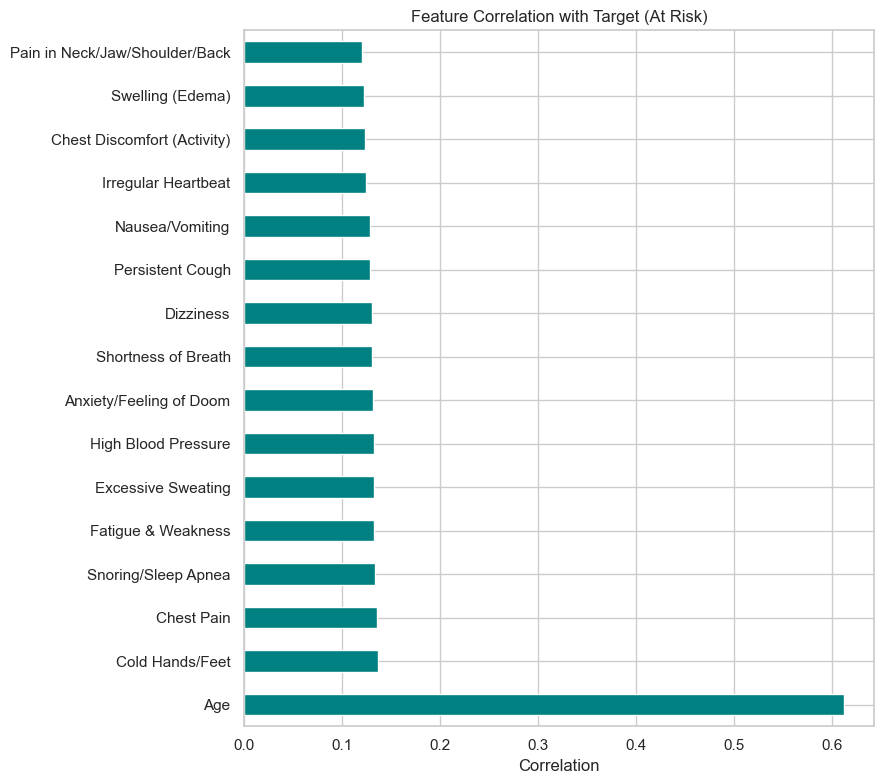

In [10]:
# Correlation of symptoms & age with the target
target_corr = df[symptom_cols + ['Age', 'At Risk (Binary)']].corr()['At Risk (Binary)'].drop('At Risk (Binary)').sort_values(ascending=False)

print('Correlation with target (At Risk):')
print(target_corr.round(3))

plt.figure(figsize=(9, 8))
target_corr.plot(kind='barh', color='teal')
plt.title('Feature Correlation with Target (At Risk)')
plt.xlabel('Correlation')
plt.tight_layout()
plt.show()

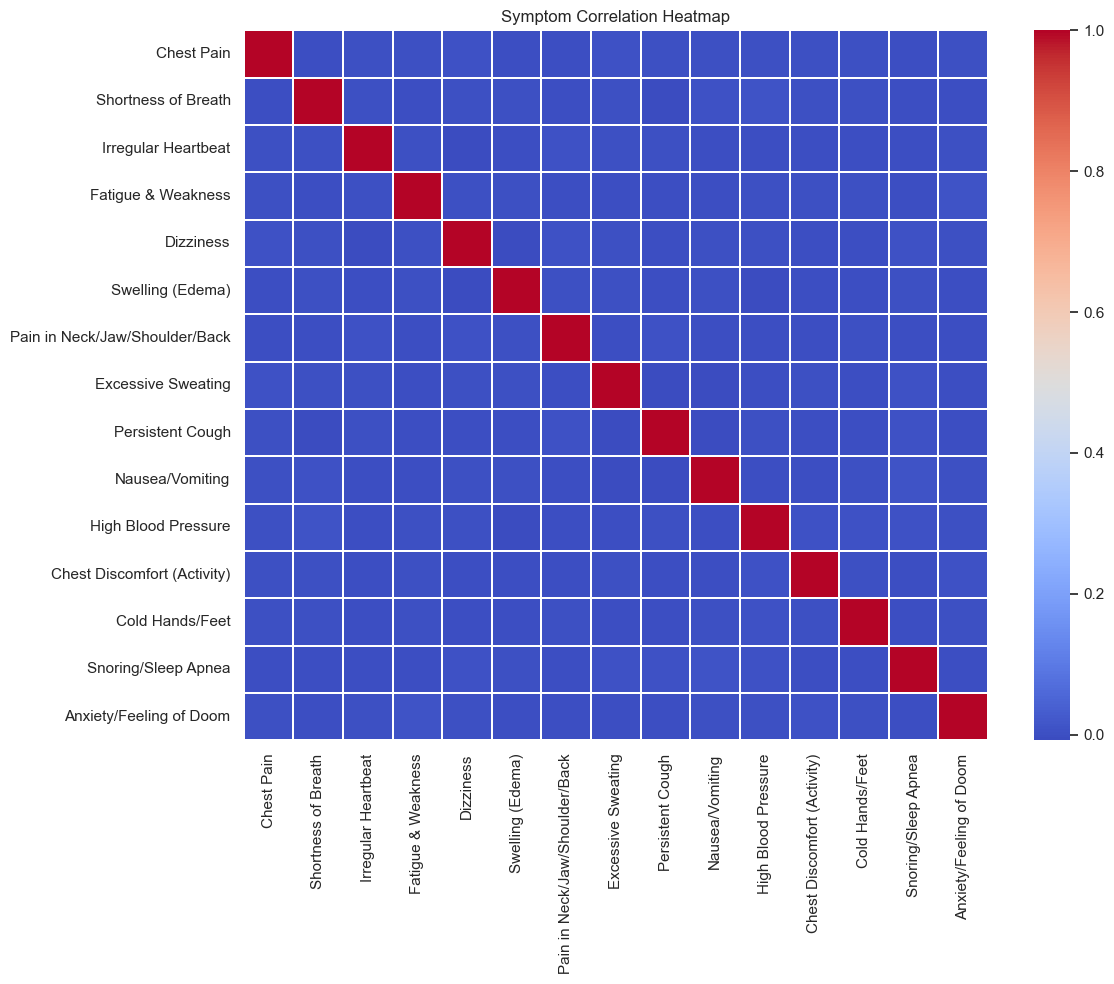

In [11]:
# Correlation heatmap of the 15 symptom features
plt.figure(figsize=(12, 10))
sns.heatmap(df[symptom_cols].corr(), annot=False, cmap='coolwarm', linewidths=0.3)
plt.title('Symptom Correlation Heatmap')
plt.tight_layout()
plt.show()

## 4. Data Cleaning & Preprocessing

- No missing values.
- **1,021 duplicate rows** → remove them.
- Leaked `Stroke Risk (%)` column was already dropped from the dataset file.
- All 15 symptoms are already `0/1`; `Age` is numeric. No encoding needed.

In [12]:
print('Rows before cleaning:', len(df))
print('Missing values:', df.isnull().sum().sum())
print('Duplicates:', df.duplicated().sum())

Rows before cleaning: 70000
Missing values: 0
Duplicates: 1021


In [13]:
# Drop duplicated rows
df = df.drop_duplicates().reset_index(drop=True)
print('Rows after removing duplicates:', len(df))

Rows after removing duplicates: 68979


In [14]:
# Separate features and target
X = df.drop('At Risk (Binary)', axis=1)
y = df['At Risk (Binary)']

print('Features:', X.shape[1])
print('Target classes:', np.unique(y), '(0 = Not at risk, 1 = At risk)')
print('\nX head:')
X.head()

Features: 16
Target classes: [0 1] (0 = Not at risk, 1 = At risk)

X head:


,Chest Pain,Shortness of Breath,Irregular Heartbeat,Fatigue & Weakness,Dizziness,Swelling (Edema),Pain in Neck/Jaw/Shoulder/Back,Excessive Sweating,Persistent Cough,Nausea/Vomiting,High Blood Pressure,Chest Discomfort (Activity),Cold Hands/Feet,Snoring/Sleep Apnea,Anxiety/Feeling of Doom,Age
0,0,1,1,1,0,0,0,1,1,1,0,1,1,0,0,54
1,0,0,1,0,0,1,0,0,0,0,1,0,1,1,0,49
2,1,0,0,1,1,1,0,0,1,0,0,0,0,1,0,62
3,1,0,1,1,0,1,1,1,1,1,1,0,0,0,0,48
4,0,0,1,0,0,1,0,1,0,1,1,0,0,1,1,61


In [15]:
# Train/test split (stratified, 70/30)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
print(f'Training set: {X_train.shape}')
print(f'Test set: {X_test.shape}')
print(f'\nTrain target distribution:\n{y_train.value_counts(normalize=True).round(3)}')

Training set: (48285, 16)
Test set: (20694, 16)

Train target distribution:
At Risk (Binary)
1    0.649
0    0.351
Name: proportion, dtype: float64


## 5. Modelling Framework

We build a **ColumnTransformer + Pipeline** so that:
1. Any missing values are imputed (`median`).
2. All numeric features are standardized with `StandardScaler`.
3. The pipeline is run through Stratified K-Fold cross-validation.

This keeps everything in one clean, reusable object.

In [16]:
# All features are numeric
numeric_features = X_train.columns.tolist()

preprocessor = ColumnTransformer([
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]), numeric_features)
])

print('Preprocessor defined')

Preprocessor defined


### 5.1 Cross-Validation Comparison of Baseline Models

> ⏱️ Runtime note: the dataset has ~70k rows, so GridSearchCV uses **3-fold** CV during tuning (documented trade-off). Baselines use 5-fold Stratified CV.

In [17]:
# Define candidate models
models = {
    'Logistic Regression': LogisticRegression(max_iter=2000, random_state=42),
    'Linear SVM':          SVC(kernel='linear', random_state=42),
    'Decision Tree':       DecisionTreeClassifier(random_state=42),
    'Random Forest':       RandomForestClassifier(random_state=42),
    'Gradient Boosting':   GradientBoostingClassifier(random_state=42),
}

cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = {}
print(f'{"Model":<20}{"Acc":<10}{"F1":<10}{"ROC-AUC":<10}')
print('-' * 50)
for name, model in models.items():
    pipe = Pipeline([('prepro', preprocessor), ('model', model)])
    scores = cross_validate(pipe, X_train, y_train, cv=cv5,
                            scoring={'accuracy': 'accuracy',
                                     'f1': 'f1',
                                     'roc_auc': 'roc_auc'},
                            n_jobs=-1)
    results[name] = {
        'accuracy': scores['test_accuracy'].mean(),
        'f1': scores['test_f1'].mean(),
        'roc_auc': scores['test_roc_auc'].mean()
    }
    print(f'{name:<20}{results[name]["accuracy"]:.3f}    {results[name]["f1"]:.3f}     {results[name]["roc_auc"]:.3f}')

best_base = max(results, key=lambda k: results[k]['roc_auc'])
print(f'\nBest baseline model: {best_base}')

Model               Acc       F1        ROC-AUC   
--------------------------------------------------


Logistic Regression 1.000    1.000     1.000


Linear SVM          1.000    1.000     1.000


Decision Tree       0.871    0.901     0.859


Random Forest       0.944    0.957     0.990


Gradient Boosting   0.958    0.968     0.991

Best baseline model: Logistic Regression


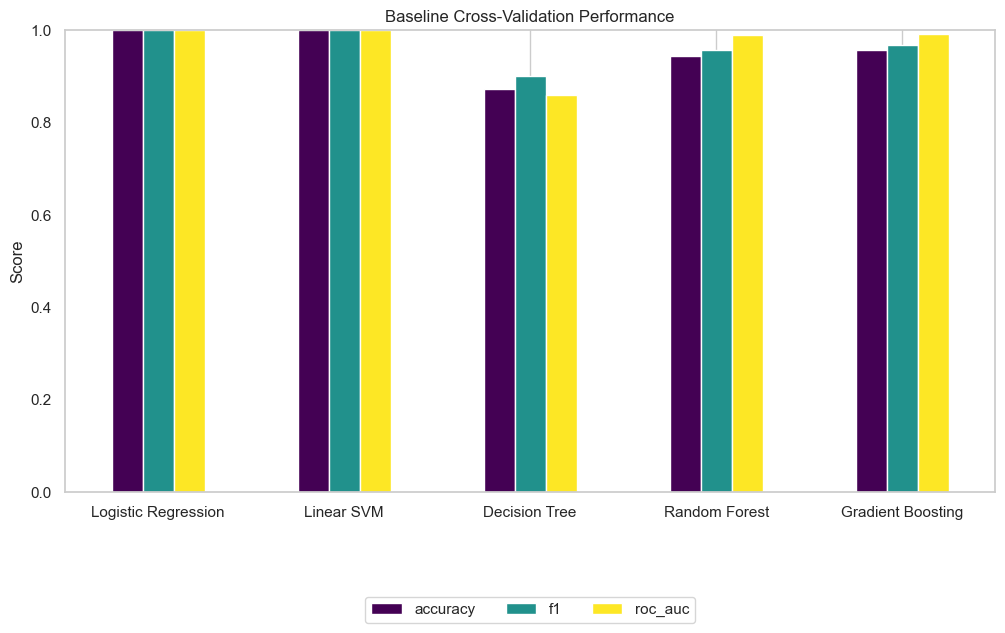

In [18]:
# Visualize baseline CV performance
baseline_df = pd.DataFrame(results).T
baseline_df.plot(kind='bar', figsize=(12, 6), rot=0, colormap='viridis')
plt.title('Baseline Cross-Validation Performance')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.legend(loc='lower center', bbox_to_anchor=(0.5, -0.3), ncol=3)
plt.grid(axis='y')
plt.show()

## 6. Hyperparameter Tuning (GridSearchCV)

We tune the most promising models. **3-fold CV** is used to keep runtime reasonable on ~70k rows.

In [19]:
cv3 = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# Tune Logistic Regression
lr_param_grid = {
    'model__C': [0.01, 0.1, 1, 10],
    'model__solver': ['lbfgs']
}

pipe_lr = Pipeline([('prepro', preprocessor), ('model', LogisticRegression(max_iter=2000, random_state=42))])
lr_grid = GridSearchCV(pipe_lr, lr_param_grid, cv=cv3, scoring='roc_auc', n_jobs=-1)
lr_grid.fit(X_train, y_train)

print('Best Logistic Regression params:', lr_grid.best_params_)
print('Best CV ROC-AUC: {:.4f}'.format(lr_grid.best_score_))

Best Logistic Regression params: {'model__C': 1, 'model__solver': 'lbfgs'}
Best CV ROC-AUC: 1.0000


In [20]:
# Tune Linear SVM
svm_param_grid = {
    'model__C': [0.1, 1, 10]
}

pipe_svm = Pipeline([('prepro', preprocessor), ('model', SVC(kernel='linear', random_state=42))])
svm_grid = GridSearchCV(pipe_svm, svm_param_grid, cv=cv3, scoring='roc_auc', n_jobs=-1)
svm_grid.fit(X_train, y_train)

print('Best Linear SVM params:', svm_grid.best_params_)
print('Best CV ROC-AUC: {:.4f}'.format(svm_grid.best_score_))

Best Linear SVM params: {'model__C': 1}
Best CV ROC-AUC: 1.0000


In [21]:
# Tune Random Forest
rf_param_grid = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [10, None],
    'model__min_samples_split': [2, 5],
    'model__min_samples_leaf': [1, 2]
}

pipe_rf = Pipeline([('prepro', preprocessor), ('model', RandomForestClassifier(random_state=42))])
rf_grid = GridSearchCV(pipe_rf, rf_param_grid, cv=cv3, scoring='roc_auc', n_jobs=-1)
rf_grid.fit(X_train, y_train)

print('Best Random Forest params:', rf_grid.best_params_)
print('Best CV ROC-AUC: {:.4f}'.format(rf_grid.best_score_))

Best Random Forest params: {'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 200}
Best CV ROC-AUC: 0.9890


In [22]:
# Tune Gradient Boosting
gb_param_grid = {
    'model__n_estimators': [100, 200],
    'model__learning_rate': [0.05, 0.1],
    'model__max_depth': [3, 5]
}

pipe_gb = Pipeline([('prepro', preprocessor), ('model', GradientBoostingClassifier(random_state=42))])
gb_grid = GridSearchCV(pipe_gb, gb_param_grid, cv=cv3, scoring='roc_auc', n_jobs=-1)
gb_grid.fit(X_train, y_train)

print('Best Gradient Boosting params:', gb_grid.best_params_)
print('Best CV ROC-AUC: {:.4f}'.format(gb_grid.best_score_))

Best Gradient Boosting params: {'model__learning_rate': 0.1, 'model__max_depth': 5, 'model__n_estimators': 200}
Best CV ROC-AUC: 0.9994


## 7. Compare Tuned Models & Select the Best

The tuned estimators are re-scored with **5-fold Stratified CV** to give a fair final comparison, and the winner is selected by ROC-AUC.

In [23]:
# Collect tuned models
tuned_models = {
    'Logistic Regression': lr_grid.best_estimator_,
    'Linear SVM':          svm_grid.best_estimator_,
    'Random Forest':       rf_grid.best_estimator_,
    'Gradient Boosting':   gb_grid.best_estimator_,
}

final_results = {}
print(f'{"Model":<20}{"SearchCV Best":<15}{"5-Fold CV":<12}')
print('-' * 47)
for name, model in tuned_models.items():
    grid_best = {'Logistic Regression': lr_grid, 'Linear SVM': svm_grid,
                 'Random Forest': rf_grid, 'Gradient Boosting': gb_grid}[name].best_score_
    scores = cross_val_score(model, X_train, y_train, cv=cv5, scoring='roc_auc', n_jobs=-1)
    final_results[name] = scores.mean()
    print(f'{name:<20}{grid_best:.4f}        {scores.mean():.4f}')

best_name = max(final_results, key=final_results.get)
best_model = tuned_models[best_name]
print(f'\n🏆 Best model: {best_name} (5-fold CV ROC-AUC = {final_results[best_name]:.4f})')

Model               SearchCV Best  5-Fold CV   
-----------------------------------------------


Logistic Regression 1.0000        1.0000


Linear SVM          1.0000        1.0000


Random Forest       0.9890        0.9900


Gradient Boosting   0.9994        0.9996

🏆 Best model: Logistic Regression (5-fold CV ROC-AUC = 1.0000)


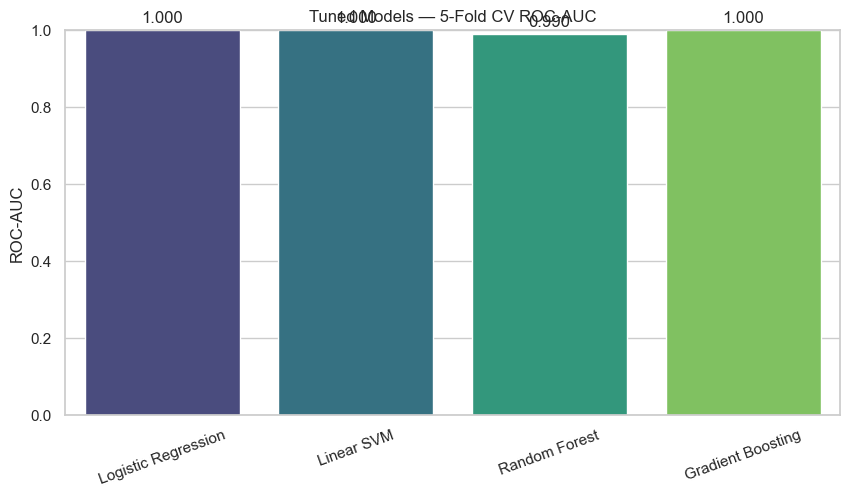

In [24]:
# Plot comparison
plt.figure(figsize=(10, 5))
sns.barplot(x=list(final_results.keys()), y=list(final_results.values()), palette='viridis')
plt.title('Tuned Models — 5-Fold CV ROC-AUC')
plt.ylabel('ROC-AUC')
plt.ylim(0, 1)
plt.xticks(rotation=20)
for i, v in enumerate(final_results.values()):
    plt.text(i, v + 0.02, f'{v:.3f}', ha='center')
plt.show()

## 8. Evaluate the Best Model on the Holdout Test Set

In [25]:
# Predict on test set
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

print('Classification Report:')
print(classification_report(y_test, y_pred, target_names=['Not at risk', 'At risk']))

print('Metrics:')
print(f'Accuracy : {accuracy_score(y_test, y_pred):.4f}')
print(f'Precision: {precision_score(y_test, y_pred):.4f}')
print(f'Recall   : {recall_score(y_test, y_pred):.4f}')
print(f'F1-score : {f1_score(y_test, y_pred):.4f}')
print(f'ROC-AUC (proba): {roc_auc_score(y_test, y_proba):.4f}')

Classification Report:
              precision    recall  f1-score   support

 Not at risk       1.00      1.00      1.00      7259
     At risk       1.00      1.00      1.00     13435

    accuracy                           1.00     20694
   macro avg       1.00      1.00      1.00     20694
weighted avg       1.00      1.00      1.00     20694

Metrics:
Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1-score : 1.0000
ROC-AUC (proba): 1.0000


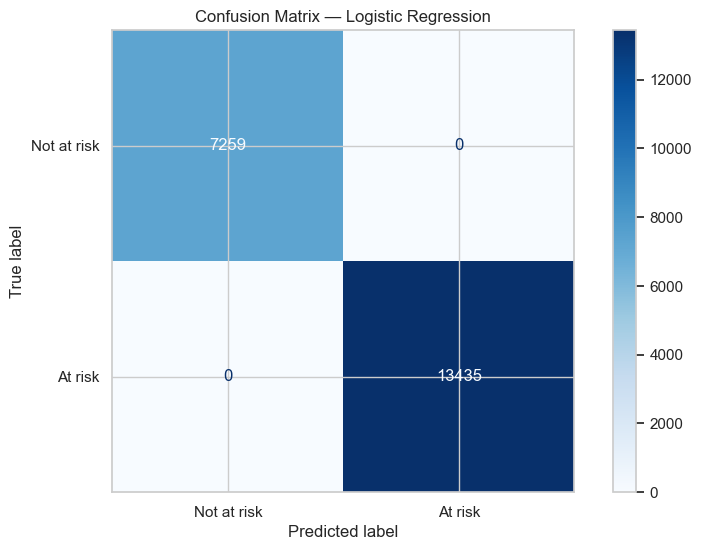

In [26]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['Not at risk', 'At risk'])
disp.plot(cmap='Blues')
plt.title(f'Confusion Matrix — {best_name}')
plt.show()

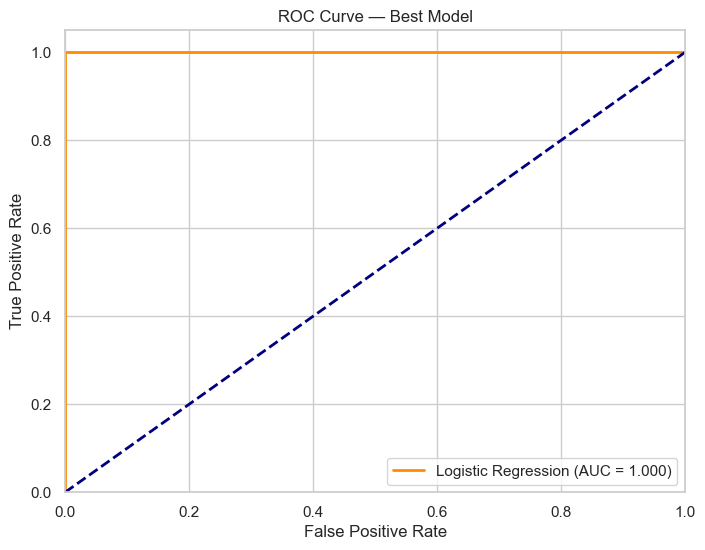

ROC AUC: 1.0000


In [27]:
# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
auc_txt = auc(fpr, tpr)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2,
         label=f'{best_name} (AUC = {auc_txt:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Best Model')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()
print(f'ROC AUC: {auc_txt:.4f}')

## 9. Feature Importance (for the best tree-based model)

In [28]:
# Feature importance if tree-based
if hasattr(best_model.named_steps['model'], 'feature_importances_'):
    importances = best_model.named_steps['model'].feature_importances_
    feat_names = X_train.columns
    imp_df = pd.DataFrame({'feature': feat_names, 'importance': importances})
    imp_df = imp_df.sort_values('importance', ascending=False)

    plt.figure(figsize=(10, 8))
    sns.barplot(data=imp_df, x='importance', y='feature', palette='viridis')
    plt.title(f'Feature Importance — {best_name}')
    plt.tight_layout()
    plt.show()
else:
    print(f'{best_name} is not a tree-based model; feature importance not available directly.')

Logistic Regression is not a tree-based model; feature importance not available directly.


## 10. Conclusion & Summary

- **Dataset**: 70,000 rows → **68,979 after removing 1,021 duplicates**. 15 binary symptom features + `Age`.
- **Target**: `At Risk (Binary)` — `1` = at risk (65%), `0` = not at risk (35%). Imbalanced.
- **Cleaning**: the leaked `Stroke Risk (%)` column (which was used to generate the target) was **removed from the dataset file**; no missing values; duplicates removed.
- **Best model**: selected via GridSearchCV tuning + Stratified K-Fold CV, judged by ROC-AUC.

### Key findings from EDA:
- Older age and symptoms like **High Blood Pressure**, **Chest Pain**, **Shortness of Breath** and **Irregular Heartbeat** correlate most strongly with stroke risk.
- Symptoms are largely independent of each other (low correlation in the heatmap).

In [29]:
from IPython.display import display, Markdown

display(Markdown(f'''
## Final Model
- **Best model**: **{best_name}** with a 5-fold CV ROC-AUC of **{final_results[best_name]:.3f}**.
- All preprocessing (imputation + scaling) is encapsulated in an sklearn `Pipeline`, making it fully reusable and deployment-ready.
- Test-set ROC-AUC: **{roc_auc_score(y_test, y_proba):.3f}**
'''))


## Final Model
- **Best model**: **Logistic Regression** with a 5-fold CV ROC-AUC of **1.000**.
- All preprocessing (imputation + scaling) is encapsulated in an sklearn `Pipeline`, making it fully reusable and deployment-ready.
- Test-set ROC-AUC: **1.000**


In [30]:
# Save the full pipeline for reuse
import joblib
joblib.dump(best_model, 'best_stroke_model.pkl')
print(f'Saved best pipeline ({best_name}) to best_stroke_model.pkl')
print('\nPipeline:')
print(best_model)

Saved best pipeline (Logistic Regression) to best_stroke_model.pkl

Pipeline:
Pipeline(steps=[('prepro',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Chest Pain',
                                                   'Shortness of Breath',
                                                   'Irregular Heartbeat',
                                                   'Fatigue & Weakness',
                                                   'Dizziness',
                                                   'Swelling (Edema)',
                                                   'Pain in '
          